In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("retail_business_data.csv")
df.head(10)

,TransactionID,Category,Region,Season,Units_Sold,Unit_Price,Inventory_Days,Revenue,Cost,Profit
0,1,Home & Kitchen,South,Fall,33,171.15,88,5647.95,4233.196879,1414.753121
1,2,Toys,South,Summer,33,88.99,24,2936.67,2131.075740,805.594260
2,3,Groceries,South,Fall,43,325.19,16,13983.17,12227.635728,1755.534272
3,4,Toys,East,Fall,37,197.19,51,7296.03,5170.829028,2125.200972
4,5,Toys,East,Summer,12,118.55,5,1422.60,1101.343496,321.256504
5,6,Clothing,West,Summer,3,136.64,18,409.92,323.705333,86.214667
6,7,Groceries,West,Summer,1,183.37,68,183.37,110.742339,72.627661
7,8,Groceries,North,Spring,33,133.68,42,4411.44,3525.010591,886.429409
8,9,Groceries,North,Winter,40,229.35,41,9174.00,5994.390588,3179.609412
9,10,Toys,West,Spring,10,21.00,15,210.00,186.547430,23.452570


In [12]:
print("Shape of dataset:", df.shape)
print("\nMissing values:\n", df.isnull().sum().reset_index())

Shape of dataset: (200, 10)

Missing values:
             index  0
0   TransactionID  0
1        Category  0
2          Region  0
3          Season  0
4      Units_Sold  0
5      Unit_Price  0
6  Inventory_Days  0
7         Revenue  0
8            Cost  0
9          Profit  0


In [14]:
# Calculate Profit Margin
df["Profit_Margin"] = (df["Profit"] / df["Revenue"]) * 100
print(df.head())

   TransactionID        Category Region  Season  Units_Sold  Unit_Price  \
0              1  Home & Kitchen  South    Fall          33      171.15   
1              2            Toys  South  Summer          33       88.99   
2              3       Groceries  South    Fall          43      325.19   
3              4            Toys   East    Fall          37      197.19   
4              5            Toys   East  Summer          12      118.55   

   Inventory_Days   Revenue          Cost       Profit  Profit_Margin  
0              88   5647.95   4233.196879  1414.753121      25.048967  
1              24   2936.67   2131.075740   805.594260      27.432237  
2              16  13983.17  12227.635728  1755.534272      12.554623  
3              51   7296.03   5170.829028  2125.200972      29.128183  
4               5   1422.60   1101.343496   321.256504      22.582349  


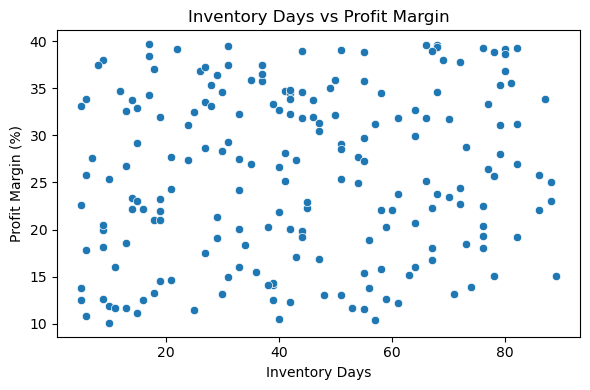

In [27]:
# Inventory Days vs Profitability
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Inventory_Days"], y=df["Profit_Margin"] )
plt.title(f"Inventory Days vs Profit Margin")
plt.xlabel("Inventory Days")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

                  Revenue        Profit  Profit_Margin
Category                                              
Clothing        228827.40  56750.908818      24.800749
Electronics     245124.17  64261.628377      26.215949
Groceries       232830.27  61845.433545      26.562454
Home & Kitchen  301915.80  86507.184353      28.652752
Toys            246784.80  63854.894969      25.874728


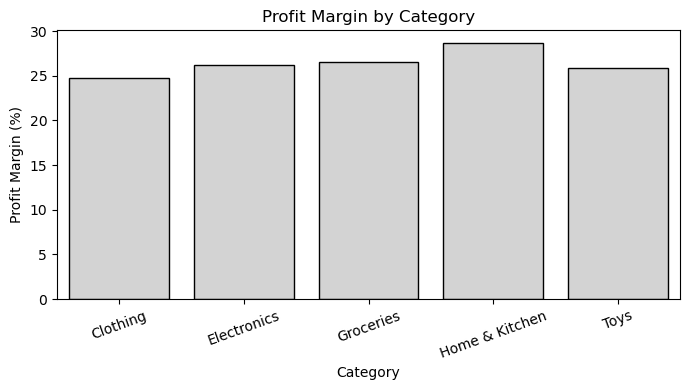

In [42]:
# Category-Wise Profitability
category_profit = df.groupby("Category")[["Revenue", "Profit"]].sum()
category_profit["Profit_Margin"] = (category_profit["Profit"] / category_profit["Revenue"]) * 100
print(category_profit)

# Bar chart
plt.figure(figsize=(7,4))
sns.barplot(x=category_profit.index, y=category_profit["Profit_Margin"], color="lightgrey",edgecolor="black")
plt.title("Profit Margin by Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

          Revenue        Profit  Profit_Margin
Season                                        
Fall    297616.65  79234.832998      26.623118
Spring  267851.05  70377.935206      26.275027
Summer  365536.90  99994.598314      27.355541
Winter  324477.84  83612.683543      25.768380


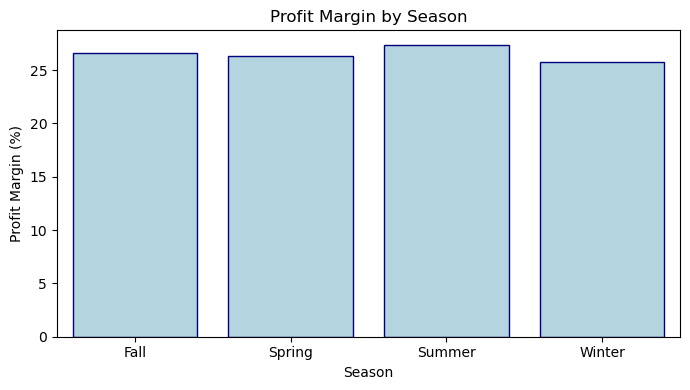

In [45]:
# Seasonal Profitability
seasonal_profit = df.groupby("Season")[["Revenue", "Profit"]].sum()
seasonal_profit["Profit_Margin"] = (seasonal_profit["Profit"] / seasonal_profit["Revenue"]) * 100
print(seasonal_profit)

# Bar chart
plt.figure(figsize=(7,4))
sns.barplot(x=seasonal_profit.index, y=seasonal_profit["Profit_Margin"], color="lightblue",edgecolor="navy")
plt.title("Profit Margin by Season")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()


Category   Clothing  Electronics  Groceries  Home & Kitchen       Toys
Region                                                                
East      29.467866    33.084681  17.220182       25.442360  25.379197
North     21.894350    28.004387  26.104700       29.128802  21.120213
South     23.570968    21.877096  27.407238       28.666311  26.348615
West      25.761608    24.030763  28.931448       30.238833  28.135236


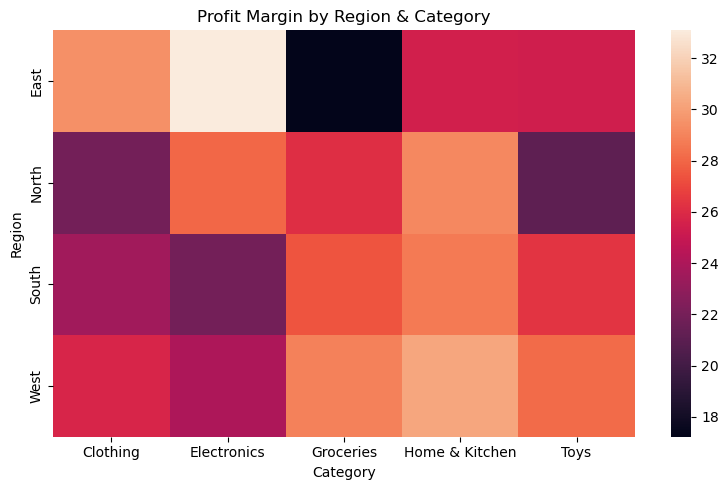

In [48]:
# Group by Region and Category
region_category = df.groupby(["Region", "Category"])[["Revenue", "Profit"]].sum()
region_category["Profit_Margin"] = (region_category["Profit"] / region_category["Revenue"]) * 100

# Reset index for pivot
pivot_table = region_category.reset_index().pivot(index="Region", columns="Category", values="Profit_Margin")

print(pivot_table)

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(pivot_table)
plt.title("Profit Margin by Region & Category")
plt.ylabel("Region")
plt.xlabel("Category")
plt.tight_layout()
plt.show()
